Hybrid Ensemble (ResNet50 + EfficientNetB0)

In [15]:
import os, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    roc_curve, auc
)

import cv2


In [16]:
TEST_DIR = "../dataset/test"
IMG_SIZE = 224
BATCH_SIZE = 8  # CPU-safe

RESNET_MODEL_PATH = "../models/resnet50_best.h5"
EFF_MODEL_PATH    = "../models/efficientnetb0_best.h5"


In [17]:
resnet_model = load_model(RESNET_MODEL_PATH)
eff_model    = load_model(EFF_MODEL_PATH)

print("Loaded ResNet50:", RESNET_MODEL_PATH)
print("Loaded EfficientNetB0:", EFF_MODEL_PATH)


Loaded ResNet50: ../models/resnet50_best.h5
Loaded EfficientNetB0: ../models/efficientnetb0_best.h5


In [18]:
def resnet_preprocessing(img):
    img = img.astype(np.uint8)

    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    gray = cv2.GaussianBlur(gray, (3,3), 0)

    gray = gray.astype(np.float32) / 255.0

    out = np.stack([gray, gray, gray], axis=-1)
    return out


In [19]:
import cv2
import numpy as np
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input

def efficientnet_preprocessing(img):
    img = img.astype(np.uint8)

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    gray = clahe.apply(gray)

    # Gaussian Blur
    gray = cv2.GaussianBlur(gray, (3,3), 0)

    # Back to 3-channel
    x = np.stack([gray, gray, gray], axis=-1).astype(np.float32)

    # EfficientNet expected preprocessing
    x = eff_preprocess_input(x)

    return x


Two Test Generators (Same images, different preprocessing)   

In [20]:
resnet_test_gen = ImageDataGenerator(preprocessing_function=resnet_preprocessing)
eff_test_gen    = ImageDataGenerator(preprocessing_function=efficientnet_preprocessing)

resnet_test_data = resnet_test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)

eff_test_data = eff_test_gen.flow_from_directory(
    TEST_DIR, target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode="binary",
    shuffle=False
)

# Sanity check: same file order
assert resnet_test_data.filenames == eff_test_data.filenames, "Test generators are not aligned!"
print("✅ Test generators aligned.")


Found 437 images belonging to 2 classes.
Found 437 images belonging to 2 classes.
✅ Test generators aligned.


In [21]:
resnet_test_data.reset()
eff_test_data.reset()

p_resnet = resnet_model.predict(resnet_test_data, verbose=1).ravel()
p_eff    = eff_model.predict(eff_test_data, verbose=1).ravel()

y_true = resnet_test_data.classes  # same as eff_test_data.classes

print("Shapes:", p_resnet.shape, p_eff.shape, y_true.shape)


55/55 [==============================] - 46s 813ms/step
Shapes: (437,) (437,) (437,)


Hybrid Probability (Average)

In [22]:
p_hybrid = (p_resnet + p_eff) / 2.0


Evaluate Hybrid at Threshold = 0.5 (default)

In [29]:
threshold = 0.5
y_pred = (p_hybrid >= threshold).astype(int)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)

fpr, tpr, _ = roc_curve(y_true, p_hybrid)
roc_auc = auc(fpr, tpr)

print(f"Hybrid (thr={threshold}):")
print({"accuracy": acc, "precision": prec, "recall": rec, "f1": f1, "auc": roc_auc})
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=["Normal", "Stroke"], zero_division=0))


Hybrid (thr=0.5):
{'accuracy': 0.8123569794050344, 'precision': 0.6348314606741573, 'recall': 0.8692307692307693, 'f1': 0.7337662337662337, 'auc': 0.9069406163868704}

Classification Report:

              precision    recall  f1-score   support

      Normal       0.93      0.79      0.86       307
      Stroke       0.63      0.87      0.73       130

    accuracy                           0.81       437
   macro avg       0.78      0.83      0.79       437
weighted avg       0.85      0.81      0.82       437



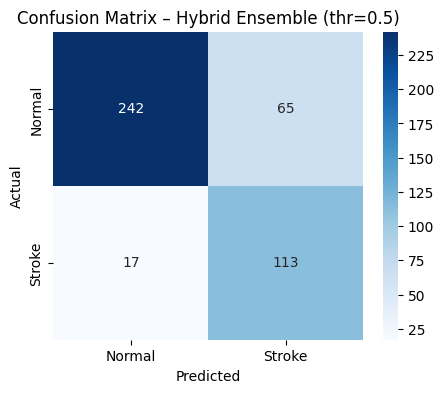

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Normal","Stroke"],
    yticklabels=["Normal","Stroke"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix – Hybrid Ensemble (thr={threshold})")
plt.show()


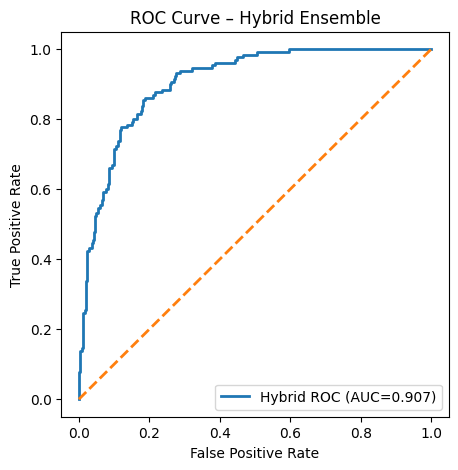

In [25]:
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f"Hybrid ROC (AUC={roc_auc:.3f})")
plt.plot([0,1],[0,1], lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Hybrid Ensemble")
plt.legend(loc="lower right")
plt.show()


In [26]:
thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

rows = []
for thr in thresholds:
    yp = (p_hybrid >= thr).astype(int)
    rows.append([
        thr,
        accuracy_score(y_true, yp),
        precision_score(y_true, yp, zero_division=0),
        recall_score(y_true, yp, zero_division=0),
        f1_score(y_true, yp, zero_division=0),
    ])

print("thr | acc | prec | recall | f1")
for r in rows:
    print(f"{r[0]:.2f} | {r[1]:.3f} | {r[2]:.3f} | {r[3]:.3f} | {r[4]:.3f}")


thr | acc | prec | recall | f1
0.30 | 0.597 | 0.424 | 0.992 | 0.594
0.35 | 0.670 | 0.474 | 0.977 | 0.638
0.40 | 0.719 | 0.515 | 0.954 | 0.668
0.45 | 0.780 | 0.582 | 0.931 | 0.716
0.50 | 0.812 | 0.635 | 0.869 | 0.734
0.55 | 0.824 | 0.667 | 0.815 | 0.734
0.60 | 0.849 | 0.732 | 0.777 | 0.754


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

weights = [i/10 for i in range(0, 11)]          # 0.0 to 1.0
thresholds = [i/100 for i in range(30, 81, 2)]  # 0.30 to 0.80 step 0.02

best_acc = -1
best_row = None

all_rows = []

for w in weights:
    p = w * p_resnet + (1 - w) * p_eff
    for thr in thresholds:
        y_pred = (p >= thr).astype(int)
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        all_rows.append((w, thr, acc, prec, rec, f1))

        if acc > best_acc:
            best_acc = acc
            best_row = (w, thr, acc, prec, rec, f1)

print("✅ Best by Accuracy:")
print("w, thr, acc, prec, rec, f1 =", best_row)


✅ Best by Accuracy:
w, thr, acc, prec, rec, f1 = (0.5, 0.6, 0.8489702517162472, 0.7318840579710145, 0.7769230769230769, 0.753731343283582)


In [28]:
def final_classification(p_final, threshold=0.6):
    if p_final >= threshold:
        return "Stroke"
    else:
        return "Normal"
